## Practical 6

# Setup and Loading Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Load the cleaned dataset
df = pd.read_csv('../data/heart_clean.csv')

# Display the first few rows
display(df.head())

,id,age,sex,dataset,trestbps,chol,fbs,thalch,exang,oldpeak,...,num,cp_atypical angina,cp_non-anginal,cp_typical angina,thal_normal,thal_reversable defect,slope_flat,slope_upsloping,restecg_normal,restecg_st-t abnormality
0,-1.730169,1.007386,Male,Cleveland,0.698041,0.311021,True,0.495698,False,1.349421,...,0,False,False,True,False,False,False,False,False,False
1,-1.726404,1.432034,Male,Cleveland,1.511761,0.797713,False,-1.175955,True,0.589832,...,2,False,False,False,True,False,True,False,False,False
2,-1.722639,1.432034,Male,Cleveland,-0.658158,0.274289,False,-0.340128,True,1.634267,...,1,False,False,False,False,True,True,False,False,False
3,-1.718873,-1.752828,Male,Cleveland,-0.115679,0.467130,False,1.968345,False,2.488805,...,0,False,True,False,True,False,False,False,True,False
4,-1.715108,-1.328180,Female,Cleveland,-0.115679,0.044717,False,1.371326,False,0.494884,...,0,True,False,False,True,False,False,True,False,False


# Define Features (X) and Target (y)

In [3]:

y = df['thalch']

X = df.drop(columns=['thalch', 'num', 'id', 'dataset'], errors='ignore')

X = pd.get_dummies(X, drop_first=True)

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (920, 17)
Target (y) shape: (920,)


# Train-Validation Split and Scaling

In [4]:

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=31)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Data successfully split and scaled!")
print("Training records:", X_train_scaled.shape[0])
print("Validation records:", X_val_scaled.shape[0])

Data successfully split and scaled!
Training records: 644
Validation records: 276


# Train and Evaluate All Three Models

In [5]:
print("--- Model Training and Validation MSE ---")

# 1. Standard Multiple Linear Regression (No Regularization)
lreg = LinearRegression()
lreg.fit(X_train_scaled, y_train)
mse_linear = mean_squared_error(y_val, lreg.predict(X_val_scaled))
print(f"Linear Regression Validation MSE : {mse_linear:.4f}")

# 2. Lasso Regression (L1 Regularization
lasso = Lasso(alpha=0.05) 
lasso.fit(X_train_scaled, y_train)
mse_lasso = mean_squared_error(y_val, lasso.predict(X_val_scaled))
print(f"Lasso Regression Validation MSE  : {mse_lasso:.4f}")

# 3. Ridge Regression (L2 Regularization 
ridge = Ridge(alpha=5.0)
ridge.fit(X_train_scaled, y_train)
mse_ridge = mean_squared_error(y_val, ridge.predict(X_val_scaled))
print(f"Ridge Regression Validation MSE  : {mse_ridge:.4f}")

--- Model Training and Validation MSE ---
Linear Regression Validation MSE : 0.6662
Lasso Regression Validation MSE  : 0.6596
Ridge Regression Validation MSE  : 0.6649


# Visualizing the Coefficients (The Bias-Variance Effect)

Coefficient Values:


,Feature,Linear,Lasso,Ridge
0,age,-0.304887,-0.243372,-0.302068
1,trestbps,-0.047430,-0.000000,-0.047044
2,chol,0.149090,0.138407,0.148996
3,fbs,0.004683,-0.000000,0.004323
4,exang,-0.200004,-0.169972,-0.198980
5,oldpeak,0.117094,0.002520,0.113755
6,ca,-0.043158,-0.003744,-0.043075
7,cp_atypical angina,0.175912,0.089770,0.173983
8,cp_non-anginal,0.178266,0.103330,0.176439
9,cp_typical angina,0.085554,0.027420,0.084600


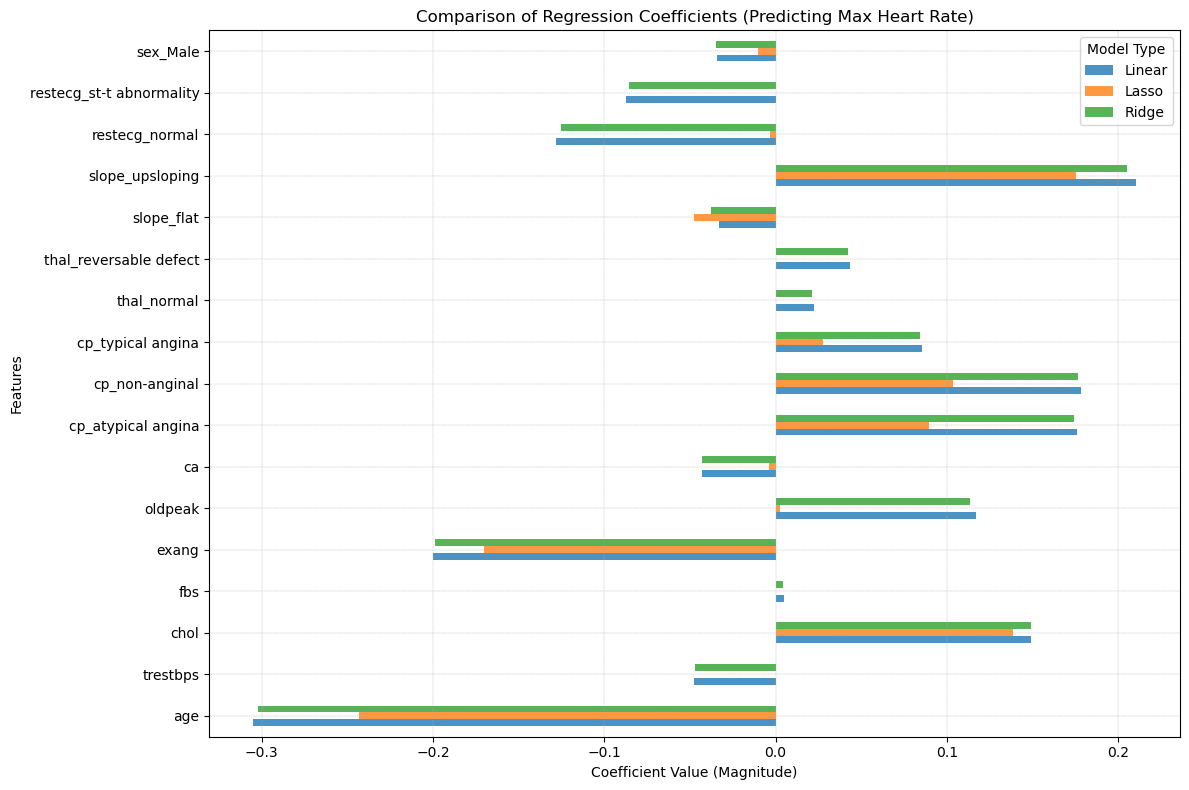

In [6]:

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lreg.coef_,
    'Lasso': lasso.coef_,
    'Ridge': ridge.coef_
})


# Plotting the comparison graph


plt.title("Comparison of Regression Coefficients (Predicting Max Heart Rate)")
plt.xlabel("Coefficient Value (Magnitude)")
plt.ylabel("Features")
plt.grid(True, linewidth=0.3, linestyle='--')
plt.legend(title="Model Type")
plt.tight_layout()
plt.show()

# Notice how Lasso pushes less important feature coefficients to exactly 0.0!